Mean RT per condition (s):
condition
LONG     0.392078
SHORT    0.479236
Name: response_time, dtype: float64
Saved - /home/qmoreau/gogo_bursts/stat_output/PC12_STIM_burst_RT_overall_perm.pdf


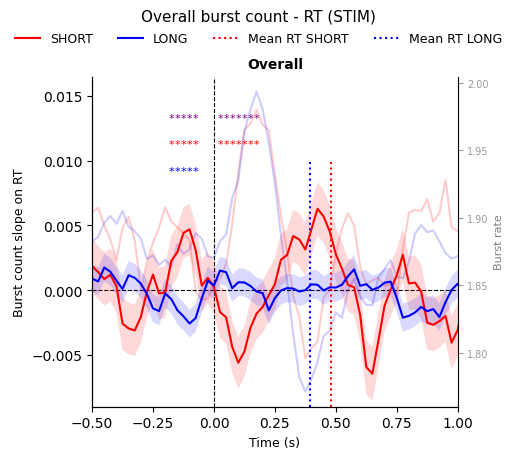

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path("/home/qmoreau/gogo_bursts/stat_output")
pc    = 12
epoch = "STIM"

short_color = np.array([255, 0, 0]) / 255.0
long_color  = np.array([0,   0, 255]) / 255.0

CONDITION_COLORS = {"SHORT": short_color, "LONG": long_color}
XLIM  = (-0.5, 1)
ALPHA = 0.15

trends = pd.read_csv(data_dir / f"PC_{pc}_{epoch}_burst_rate_RT_overall.csv")
trends = trends[trends["SE"].apply(lambda x: pd.notna(x) and np.isfinite(x) and x != 0)]

windows = pd.read_csv(data_dir / f"PC_{pc}_{epoch}_RT_windows_overall.csv")

trials = pd.read_csv(data_dir / f"PC_{pc}_{epoch}_trial_burst_counts.csv")
mean_rt = (
    trials.dropna(subset=["response_time"])
    .groupby("condition")["response_time"]
    .mean()
)
print("Mean RT per condition (s):")
print(mean_rt)

# ── Grand-average burst rate per condition (background) ───────────────────────
time_cols = [c for c in trials.columns if c.startswith("time_")]
if not time_cols:
    print("No time_* columns found. Available columns:")
    print(trials.columns.tolist())
time_vals = np.array([float(c.replace("time_", "")) for c in time_cols])
t_mask    = (time_vals >= XLIM[0]) & (time_vals <= XLIM[1])

grand_burst = (
    trials.groupby(["condition", "subject_id"])[time_cols].mean()
    .groupby("condition").mean()
)

trends_vis = trends[trends["time"].between(*XLIM)]
y_min  = trends_vis["estimate"].min()
y_max  = trends_vis["estimate"].max()
y_span = y_max - y_min
y_pad  = 0.2 * y_span

py_long  = y_max + 1.0 * y_pad
py_short = y_max + 1.8 * y_pad
py_ctr   = y_max + 2.6 * y_pad

fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)

ax2 = ax.twinx()
ax2.set_zorder(ax.get_zorder() - 1)
ax.patch.set_visible(False)

for cond, color in CONDITION_COLORS.items():
    ax2.plot(time_vals[t_mask], grand_burst.loc[cond].values[t_mask],
             color=color, linewidth=1.5, alpha=0.2, zorder=0)

ax2.set_ylabel("Burst rate", fontsize=8, color="0.5")
ax2.tick_params(axis="y", labelsize=7, colors="0.6")
ax2.spines[["top"]].set_visible(False)

ax.axhline(0, color="k", linestyle="--", linewidth=0.8, zorder=1)
ax.axvline(0, color="k", linestyle="--", linewidth=0.8, zorder=1)

for cond, color in CONDITION_COLORS.items():
    if cond in mean_rt.index:
        ax.vlines(mean_rt[cond], ymin=y_min - y_pad, ymax=0.01,
                  color=color, linestyle=":", linewidth=1.5, zorder=2)

for cond, color in CONDITION_COLORS.items():
    cdf = trends[trends["condition"] == cond].sort_values("time")
    ax.fill_between(
        cdf["time"],
        cdf["estimate"] - cdf["SE"],
        cdf["estimate"] + cdf["SE"],
        color=color, alpha=ALPHA, linewidth=0,
    )
    ax.plot(cdf["time"], cdf["estimate"],
            color=color, linewidth=1.5, label=cond)

ax.set_ylim(y_min - y_pad, y_max + 4 * y_pad)

for _, win in windows.iterrows():
    mask = (trends["time"] >= win["start"]) & (trends["time"] <= win["end"])
    win_times = trends[mask]["time"].unique()
    win_times = win_times[(win_times >= XLIM[0]) & (win_times <= XLIM[1])]
    for t in win_times:
        if win["long_p"] < 0.05:
            ax.text(t, py_long,  "*", color=long_color,  ha="center", va="bottom", fontsize=8)
        if win["short_p"] < 0.05:
            ax.text(t, py_short, "*", color=short_color, ha="center", va="bottom", fontsize=8)
        if win["long_short_p"] < 0.05:
            ax.text(t, py_ctr,   "*", color="purple",    ha="center", va="bottom", fontsize=8)

ax.set_xlim(XLIM)
ax.set_title("Overall", fontweight="bold", fontsize=10)
ax.set_xlabel("Time (s)", fontsize=9)
ax.set_ylabel("Burst count slope on RT", fontsize=9)
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.spines[["top", "right"]].set_visible(False)

handles, labels = ax.get_legend_handles_labels()
for cond, color in CONDITION_COLORS.items():
    handles.append(plt.Line2D([0], [0], color=color, linestyle=":", linewidth=1.5))
    labels.append(f"Mean RT {cond}")

fig.legend(handles, labels,
           loc="upper center", ncol=len(CONDITION_COLORS) * 2,
           frameon=False, fontsize=9,
           bbox_to_anchor=(0.5, 1.08))

fig.suptitle(f"Overall burst count - RT ({epoch})", fontsize=11, y=1.11)

out_path = data_dir / f"PC{pc}_{epoch}_burst_RT_overall_perm.pdf"
fig.savefig(out_path, bbox_inches="tight", dpi=150)
print(f"Saved - {out_path}")
plt.show()

Time points in window [0, 0.25]: 11
Total trials: 15897
condition
LONG     12225
SHORT     3672
dtype: int64


/tmp/ipykernel_36550/2639692503.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = cm.get_cmap(CMAP)


Saved -> /home/qmoreau/gogo_bursts/stat_output/PC12_STIM_overall_scatter_trials_age_0_0.25.pdf


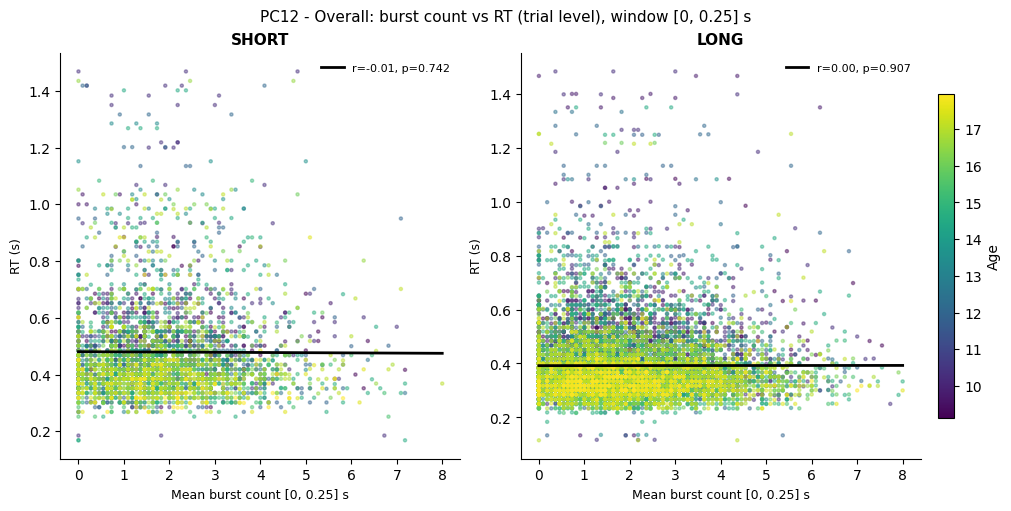

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from pathlib import Path
from scipy import stats

data_dir = Path("/home/qmoreau/gogo_bursts/stat_output")
demo_dir = Path("/home/common/bonaiuto/gogo_bursts/data_v2")
pc    = 12
epoch = "STIM"

WIN_START = 0
WIN_END   = 0.25
CMAP      = "viridis"

demo = pd.concat([
    pd.read_csv(demo_dir / "GOGO_Demographics_2025_COMO.csv"),
    pd.read_csv(demo_dir / "GOGO_Demographics_2025_Driving.csv"),
], ignore_index=True)
demo = demo[demo["Status"] == "TD"][["ParticipantID", "AgeAtImaging"]].drop_duplicates()
demo = demo.rename(columns={"ParticipantID": "subject_id", "AgeAtImaging": "age"})

trials = pd.read_csv(data_dir / f"PC_{pc}_{epoch}_trial_burst_counts.csv")
df = trials[trials["response_time"].notna()].copy()  # all tertiles

time_cols = [c for c in df.columns if c.startswith("time_")]
time_vals = np.array([float(c.replace("time_", "")) for c in time_cols])
win_cols  = [c for c, t in zip(time_cols, time_vals) if WIN_START <= t <= WIN_END]
print(f"Time points in window [{WIN_START}, {WIN_END}]: {len(win_cols)}")
df["mean_burst"] = df[win_cols].mean(axis=1)

df = df.merge(demo[["subject_id", "age"]], on="subject_id", how="inner")
print(f"Total trials: {len(df)}")
print(df.groupby("condition").size())

conditions = ["SHORT", "LONG"]
fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

age_min = df["age"].min()
age_max = df["age"].max()
norm    = mcolors.Normalize(vmin=age_min, vmax=age_max)
cmap    = cm.get_cmap(CMAP)

for ax, cond in zip(axes, conditions):
    cdf = df[df["condition"] == cond].sort_values("age")
    x      = cdf["mean_burst"].values
    y      = cdf["response_time"].values
    colors = cmap(norm(cdf["age"].values))

    ax.scatter(x, y, c=colors, s=5, alpha=0.45, zorder=2)

    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, intercept + slope * x_line,
            color="k", linewidth=2, zorder=4,
            label=f"r={r:.2f}, p={p:.3f}")

    ax.set_title(cond, fontweight="bold", fontsize=11)
    ax.set_xlabel(f"Mean burst count [{WIN_START}, {WIN_END}] s", fontsize=9)
    ax.set_ylabel("RT (s)", fontsize=9)
    ax.legend(fontsize=8, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label("Age", fontsize=10)

fig.suptitle(f"PC{pc} - Overall: burst count vs RT (trial level), window [{WIN_START}, {WIN_END}] s",
             fontsize=11)

out_path = data_dir / f"PC{pc}_{epoch}_overall_scatter_trials_age_{WIN_START}_{WIN_END}.pdf"
fig.savefig(out_path, bbox_inches="tight", dpi=150)
print(f"Saved -> {out_path}")
plt.show()


Total trials: 15897
age_quantile
0    7
1    6
2    7
3    6
4    7
Name: subject_id, dtype: int64


/tmp/ipykernel_36550/325688736.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(CMAPS[cond])
/tmp/ipykernel_36550/325688736.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "sub", [cm.get_cmap(CMAPS[cond])(0.3 + 0.65 * q / (N_QUANTILES - 1))
/tmp/ipykernel_36550/325688736.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(CMAPS[cond])
/tmp/ipykernel_36550/325688736.py:71: MatplotlibDeprecationWarning: The get_cmap 

Saved -> /home/qmoreau/gogo_bursts/stat_output/PC12_STIM_overall_scatter_slopes_age_quantiles_0_0.25.pdf


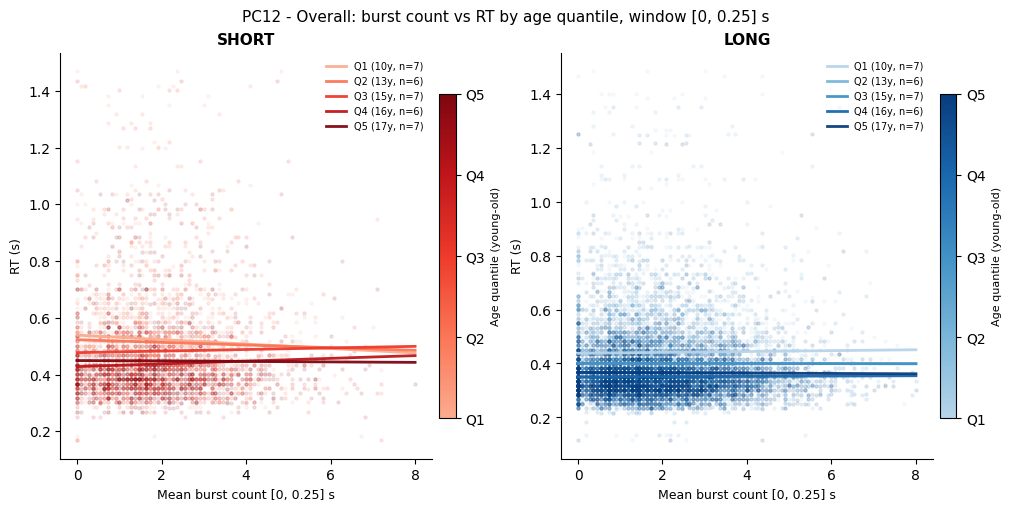

In [5]:
N_QUANTILES = 5
CMAPS = {"SHORT": "Reds", "LONG": "Blues"}

trials = pd.read_csv(data_dir / f"PC_{pc}_{epoch}_trial_burst_counts.csv")
df = trials[trials["response_time"].notna()].copy()  # all tertiles

time_cols = [c for c in df.columns if c.startswith("time_")]
time_vals = np.array([float(c.replace("time_", "")) for c in time_cols])
win_cols  = [c for c, t in zip(time_cols, time_vals) if WIN_START <= t <= WIN_END]
df["mean_burst"] = df[win_cols].mean(axis=1)

df = df.merge(demo[["subject_id", "age"]], on="subject_id", how="inner")

subj_ages = df[["subject_id", "age"]].drop_duplicates()
subj_ages = subj_ages.copy()
subj_ages["age_quantile"] = pd.qcut(subj_ages["age"], q=N_QUANTILES, labels=False)
df = df.merge(subj_ages[["subject_id", "age_quantile"]], on="subject_id", how="inner")

print(f"Total trials: {len(df)}")
print(df.groupby("age_quantile")["subject_id"].nunique())

conditions = ["SHORT", "LONG"]
fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

norm   = mcolors.Normalize(vmin=0, vmax=N_QUANTILES - 1)
x_all  = df["mean_burst"]
x_line = np.linspace(x_all.min(), x_all.max(), 100)

for ax, cond in zip(axes, conditions):
    cdf  = df[df["condition"] == cond]
    cmap = cm.get_cmap(CMAPS[cond])
    get_color = lambda q: cmap(0.3 + 0.65 * q / (N_QUANTILES - 1))

    for q in range(N_QUANTILES):
        qdf   = cdf[cdf["age_quantile"] == q]
        color = get_color(q)
        ax.scatter(qdf["mean_burst"], qdf["response_time"],
                   c=[color], s=5, alpha=0.1, zorder=2)

    for q in range(N_QUANTILES):
        qdf      = cdf[cdf["age_quantile"] == q]
        color    = get_color(q)
        mean_age = qdf["age"].mean()
        n_subj   = qdf["subject_id"].nunique()

        slopes, intercepts = [], []
        for subj, sdf in qdf.groupby("subject_id"):
            x = sdf["mean_burst"].values
            y = sdf["response_time"].values
            if len(x) < 3:
                continue
            slope, intercept, _, _, _ = stats.linregress(x, y)
            slopes.append(slope)
            intercepts.append(intercept)

        if not slopes:
            continue

        ax.plot(x_line, np.mean(intercepts) + np.mean(slopes) * x_line,
                color=color, linewidth=2, alpha=0.95, zorder=3,
                label=f"Q{q+1} ({mean_age:.0f}y, n={n_subj})")

    ax.set_title(cond, fontweight="bold", fontsize=11)
    ax.set_xlabel(f"Mean burst count [{WIN_START}, {WIN_END}] s", fontsize=9)
    ax.set_ylabel("RT (s)", fontsize=9)
    ax.legend(fontsize=7, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

    sm_cb = cm.ScalarMappable(
        cmap=mcolors.LinearSegmentedColormap.from_list(
            "sub", [cm.get_cmap(CMAPS[cond])(0.3 + 0.65 * q / (N_QUANTILES - 1))
                    for q in range(N_QUANTILES)]),
        norm=mcolors.Normalize(vmin=1, vmax=N_QUANTILES)
    )
    sm_cb.set_array([])
    cbar = fig.colorbar(sm_cb, ax=ax, shrink=0.8, pad=0.02,
                        ticks=range(1, N_QUANTILES + 1))
    cbar.set_ticklabels([f"Q{q+1}" for q in range(N_QUANTILES)])
    cbar.set_label("Age quantile (young-old)", fontsize=8)

fig.suptitle(f"PC{pc} - Overall: burst count vs RT by age quantile, window [{WIN_START}, {WIN_END}] s",
             fontsize=11)

out_path = data_dir / f"PC{pc}_{epoch}_overall_scatter_slopes_age_quantiles_{WIN_START}_{WIN_END}.pdf"
fig.savefig(out_path, bbox_inches="tight", dpi=150)
print(f"Saved -> {out_path}")
plt.show()


/tmp/ipykernel_36550/3719607517.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(CMAPS[cond])
/tmp/ipykernel_36550/3719607517.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(CMAPS[cond])


Saved -> /home/qmoreau/gogo_bursts/stat_output/PC12_STIM_overall_glm_age_tertiles_0_0.25.pdf


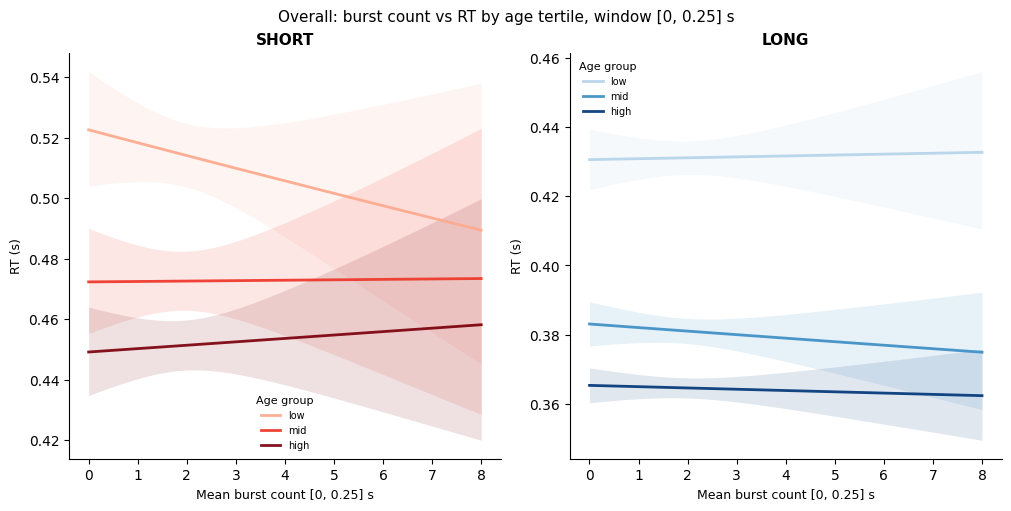

In [6]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

WIN_START   = 0
WIN_END     = 0.25
N_QUANTILES = 3
AGE_LABELS  = ["low", "mid", "high"]  # consistent with tertile labeling used elsewhere
CMAPS = {"SHORT": "Reds", "LONG": "Blues"}

trials = pd.read_csv(data_dir / f"PC_{pc}_{epoch}_trial_burst_counts.csv")
df = trials[trials["response_time"].notna()].copy()  # all tertiles

time_cols = [c for c in df.columns if c.startswith("time_")]
time_vals = np.array([float(c.replace("time_", "")) for c in time_cols])
win_cols  = [c for c, t in zip(time_cols, time_vals) if WIN_START <= t <= WIN_END]
df["mean_burst"] = df[win_cols].mean(axis=1)

df = df.merge(demo[["subject_id", "age"]], on="subject_id", how="inner")

subj_ages = df[["subject_id", "age"]].drop_duplicates().copy()
subj_ages["age_quantile"] = pd.qcut(subj_ages["age"], q=N_QUANTILES, labels=False)
df = df.merge(subj_ages[["subject_id", "age_quantile"]], on="subject_id", how="inner")

conditions = ["SHORT", "LONG"]
fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

x_line = np.linspace(df["mean_burst"].min(), df["mean_burst"].max(), 100)

for ax, cond in zip(axes, conditions):
    cdf  = df[df["condition"] == cond].copy()
    cmap = cm.get_cmap(CMAPS[cond])
    get_color = lambda q: cmap(0.3 + 0.65 * q / (N_QUANTILES - 1))

    for q in range(N_QUANTILES):
        qdf      = cdf[cdf["age_quantile"] == q].copy()
        color    = get_color(q)
        age_label = AGE_LABELS[q]

        try:
            glm = smf.glm(
                "response_time ~ mean_burst",
                data   = qdf,
                family = sm.families.Gamma(link=sm.families.links.Log())
            ).fit()

            pred_df = glm.get_prediction(
                pd.DataFrame({"mean_burst": x_line})
            ).summary_frame(alpha=0.05)

            ax.plot(x_line, pred_df["mean"],
                    color=color, linewidth=2, alpha=0.95, zorder=3,
                    label=age_label)
            ax.fill_between(x_line,
                            pred_df["mean_ci_lower"],
                            pred_df["mean_ci_upper"],
                            color=color, alpha=0.12, linewidth=0)
        except Exception as e:
            print(f"  [GLM failed {age_label} {cond}]: {e}")

    ax.set_title(cond, fontweight="bold", fontsize=11)
    ax.set_xlabel(f"Mean burst count [{WIN_START}, {WIN_END}] s", fontsize=9)
    ax.set_ylabel("RT (s)", fontsize=9)
    ax.legend(fontsize=7, frameon=False, title="Age group", title_fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"Overall: burst count vs RT by age tertile, window [{WIN_START}, {WIN_END}] s",
    fontsize=11
)

out_path = data_dir / f"PC{pc}_{epoch}_overall_glm_age_tertiles_{WIN_START}_{WIN_END}.pdf"
fig.savefig(out_path, bbox_inches="tight", dpi=150)
print(f"Saved -> {out_path}")
plt.show()

/tmp/ipykernel_36550/2588353031.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(CMAPS[cond])


Saved -> /home/qmoreau/gogo_bursts/stat_output/PC12_STIM_overall_glm_age_tertiles_SHORT_0_0.25.pdf


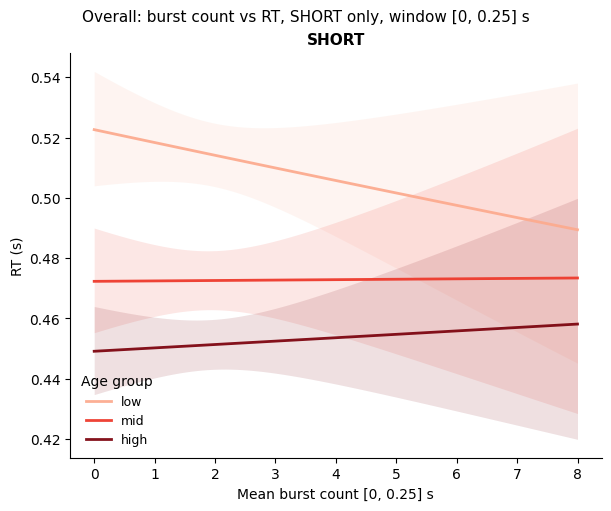

In [7]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

WIN_START   = 0
WIN_END     = 0.25
N_QUANTILES = 3
AGE_LABELS  = ["low", "mid", "high"]  # consistent with tertile labeling used elsewhere
CMAPS = {"SHORT": "Reds", "LONG": "Blues"}

trials = pd.read_csv(data_dir / f"PC_{pc}_{epoch}_trial_burst_counts.csv")
df = trials[trials["response_time"].notna()].copy()  # all tertiles

time_cols = [c for c in df.columns if c.startswith("time_")]
time_vals = np.array([float(c.replace("time_", "")) for c in time_cols])
win_cols  = [c for c, t in zip(time_cols, time_vals) if WIN_START <= t <= WIN_END]
df["mean_burst"] = df[win_cols].mean(axis=1)

df = df.merge(demo[["subject_id", "age"]], on="subject_id", how="inner")

subj_ages = df[["subject_id", "age"]].drop_duplicates().copy()
subj_ages["age_quantile"] = pd.qcut(subj_ages["age"], q=N_QUANTILES, labels=False)
df = df.merge(subj_ages[["subject_id", "age_quantile"]], on="subject_id", how="inner")

cond = "SHORT"
fig, ax = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)

cdf  = df[df["condition"] == cond].copy()
x_line = np.linspace(cdf["mean_burst"].min(), cdf["mean_burst"].max(), 100)
cmap = cm.get_cmap(CMAPS[cond])
get_color = lambda q: cmap(0.3 + 0.65 * q / (N_QUANTILES - 1))

for q in range(N_QUANTILES):
    qdf      = cdf[cdf["age_quantile"] == q].copy()
    color    = get_color(q)
    age_label = AGE_LABELS[q]

    try:
        glm = smf.glm(
            "response_time ~ mean_burst",
            data   = qdf,
            family = sm.families.Gamma(link=sm.families.links.Log())
        ).fit()

        pred_df = glm.get_prediction(
            pd.DataFrame({"mean_burst": x_line})
        ).summary_frame(alpha=0.05)

        ax.plot(x_line, pred_df["mean"],
                color=color, linewidth=2, alpha=0.95, zorder=3,
                label=age_label)
        ax.fill_between(x_line,
                        pred_df["mean_ci_lower"],
                        pred_df["mean_ci_upper"],
                        color=color, alpha=0.12, linewidth=0)
    except Exception as e:
        print(f"  [GLM failed {age_label} {cond}]: {e}")

ax.set_title(cond, fontweight="bold", fontsize=11)
ax.set_xlabel(f"Mean burst count [{WIN_START}, {WIN_END}] s", fontsize=10)
ax.set_ylabel("RT (s)", fontsize=10)
ax.legend(fontsize=9, frameon=False, title="Age group", title_fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"Overall: burst count vs RT, {cond} only, window [{WIN_START}, {WIN_END}] s",
    fontsize=11
)

out_path = data_dir / f"PC{pc}_{epoch}_overall_glm_age_tertiles_{cond}_{WIN_START}_{WIN_END}.pdf"
fig.savefig(out_path, bbox_inches="tight", dpi=150)
print(f"Saved -> {out_path}")
plt.show()